<a href="https://colab.research.google.com/github/AlishaZaheer1/Projects/blob/main/03_Color_Detection_Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Color Detection with Computer Vision
**Project:** 2024

K-means clustering is used to discover dominant colors in an image. The workflow includes image creation/loading, RGB feature extraction, clustering, dominant-color reporting, and visualization.

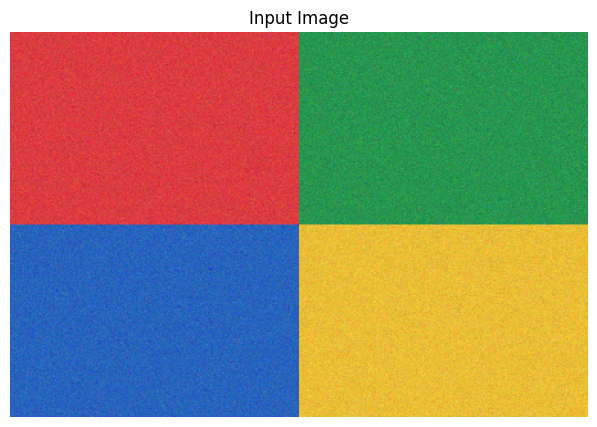

Image shape: (300, 450, 3)


In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image
np.random.seed(42)

# Create a reproducible sample image with several dominant color regions.
img=np.zeros((300,450,3),dtype=np.uint8)
img[:150,:225]=[220,60,65]       # red
img[:150,225:]=[40,150,80]       # green
img[150:,:225]=[40,100,190]      # blue
img[150:,225:]=[235,190,55]      # yellow
noise=np.random.normal(0,10,img.shape)
img=np.clip(img.astype(float)+noise,0,255).astype(np.uint8)

plt.figure(figsize=(8,5)); plt.imshow(img); plt.axis("off"); plt.title("Input Image"); plt.show()
print("Image shape:",img.shape)

In [ ]:
pixels=img.reshape(-1,3)
kmeans=KMeans(n_clusters=4,n_init=10,random_state=42)
labels=kmeans.fit_predict(pixels)
centers=np.clip(kmeans.cluster_centers_,0,255).astype(int)
counts=np.bincount(labels)
order=np.argsort(counts)[::-1]

print("Dominant RGB colors:")
for rank,i in enumerate(order,1):
    print(f"{rank}. RGB {tuple(centers[i])} — {counts[i]/len(labels):.1%} of pixels")

Dominant RGB colors:
1. RGB (np.int64(234), np.int64(189), np.int64(54)) — 25.0% of pixels
2. RGB (np.int64(39), np.int64(149), np.int64(79)) — 25.0% of pixels
3. RGB (np.int64(39), np.int64(99), np.int64(189)) — 25.0% of pixels
4. RGB (np.int64(219), np.int64(59), np.int64(64)) — 25.0% of pixels


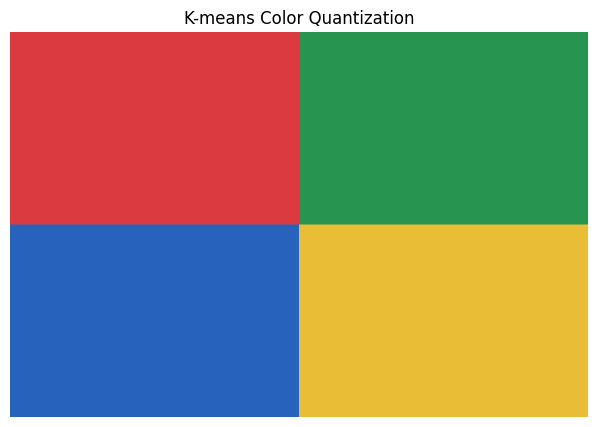

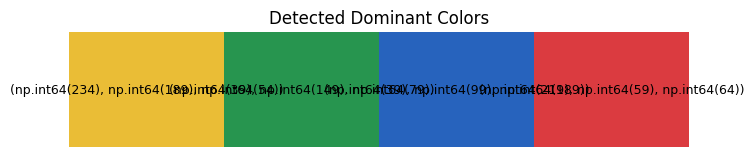

In [ ]:
# Quantized image
quant=centers[labels].reshape(img.shape).astype(np.uint8)
plt.figure(figsize=(8,5)); plt.imshow(quant); plt.axis("off")
plt.title("K-means Color Quantization")
plt.show()

fig,ax=plt.subplots(figsize=(8,1.5))
for j,i in enumerate(order):
    ax.bar(j,1,color=centers[i]/255,width=1)
    ax.text(j,.5,str(tuple(centers[i])),ha="center",va="center",fontsize=9)
ax.set_xlim(-.5,3.5); ax.set_ylim(0,1); ax.axis("off")
plt.title("Detected Dominant Colors"); plt.show()

### How to use this with a real image
Replace the sample-image cell with:
`img = np.array(Image.open("/content/your_image.jpg").convert("RGB"))`

The rest of the pipeline remains unchanged.